# Modelaje y presentación de resultados.

Aquí haremos un showcase de los resultados. Usamos Programación Orientada a Objetos para dejar acomodados de forma más ordenada los distintos modelos y resultados. Al final haremos una tabla comparativa.

Primero, cargaremos nuestra clase `compareModels` la cual tiene los métodos para hacer la predicción. También en dicha clase se encuentra los métodos para hacer `GridSearchCV`. Se encuentran métodos para hacer gráficos también.

In [1]:
import sys
sys.path.insert(0, '..')     
from modelaje import compareModels

comparacion = compareModels()
comparacion.dependent_variable

{'uci_id': 560, 'name': 'Seoul Bike Sharing Demand', 'repository_url': 'https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand', 'data_url': 'https://archive.ics.uci.edu/static/public/560/data.csv', 'abstract': 'The dataset contains count of public bicycles rented per hour in the Seoul Bike Sharing System, with corresponding weather data and holiday information', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 8760, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Functioning Day'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Mon Feb 05 2024', 'dataset_doi': '10.24432/C5F62R', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'Currently Rental bikes are introduced in many urban cities for the enhancement of mobility comfort. It is important to make the rental bike available and a

'Functioning Day'

## Regresión Lineal

In [2]:
y_pred = comparacion.linear_regression()

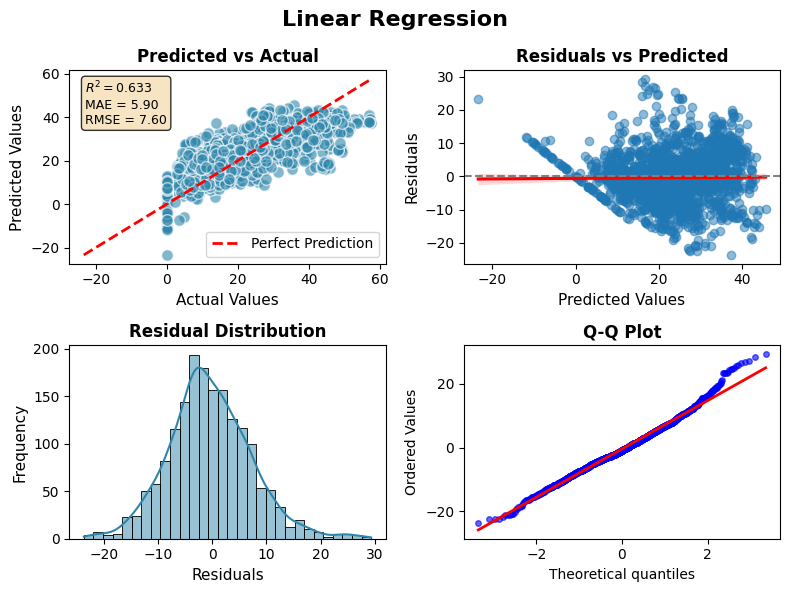

The Mean Absolute Error (MAE) is 5.904488722233003.
The Mean Squred Error(MSE) is 57.792671074378056.
The Root Mean Squared Error(RMSE) is 7.602149108928216.
The R2 Score is 0.6330303855703152.
Adjusted R2 is 0.6287904131332305.


In [3]:
comparacion.plot_results(y_pred,"Linear Regression")
comparacion.create_entry(y_pred,"Linear Regression",comparacion.comparison_table)


## Lasso

The Mean Absolute Error (MAE) is 5.905721388761708.
The Mean Squred Error(MSE) is 57.82464085446863.
The Root Mean Squared Error(RMSE) is 7.604251498633421.
The R2 Score is 0.6328273851265713.
Adjusted R2 is 0.6285850672193105.


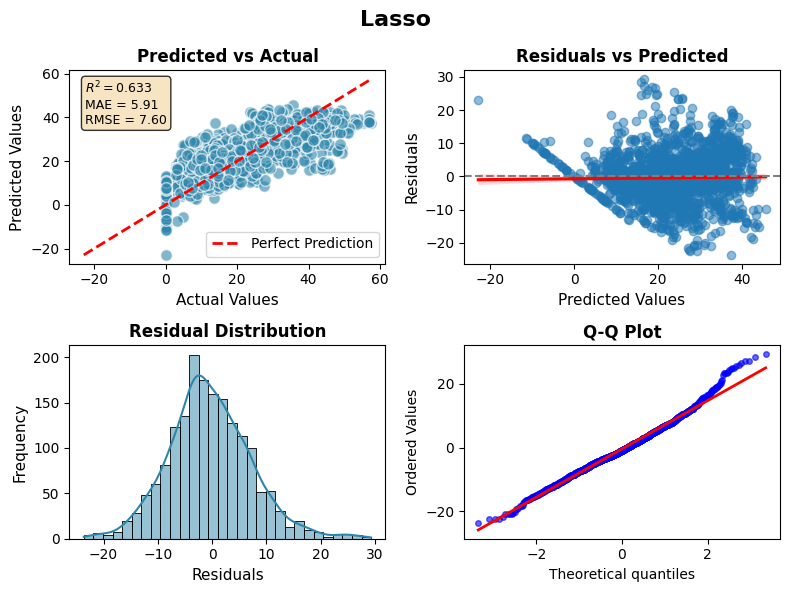

In [4]:
y_pred = comparacion.lasso()
comparacion.create_entry(y_pred,"Lasso",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Lasso")


## Ridge

The Mean Absolute Error (MAE) is 5.9044919107665335.
The Mean Squred Error(MSE) is 57.792639815821225.
The Root Mean Squared Error(RMSE) is 7.602147053025298.
The R2 Score is 0.6330305840546617.
Adjusted R2 is 0.6287906139108681.


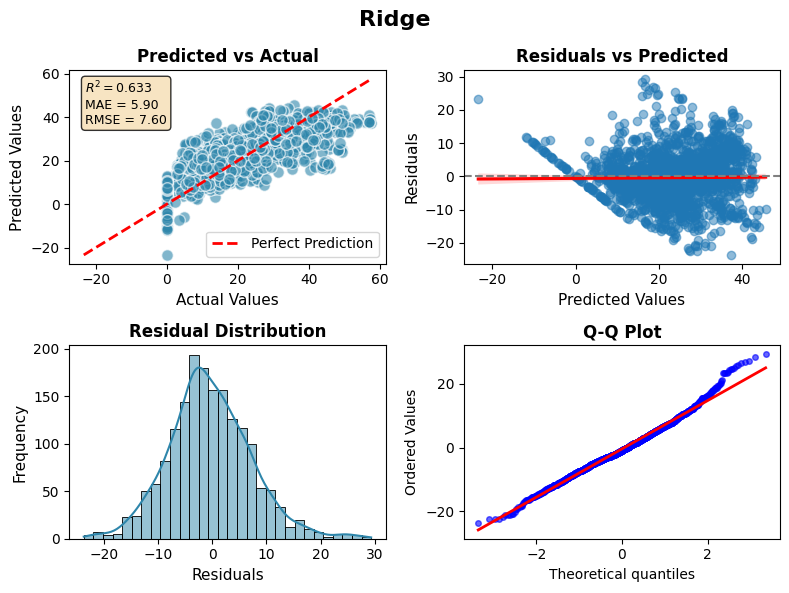

In [5]:
y_pred = comparacion.ridge()
comparacion.create_entry(y_pred,"Ridge",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Ridge")


## Elastic Net

The Mean Absolute Error (MAE) is 5.906439851284871.
The Mean Squred Error(MSE) is 57.79111126249638.
The Root Mean Squared Error(RMSE) is 7.602046518043439.
The R2 Score is 0.6330402900020391.
Adjusted R2 is 0.6288004320009073.


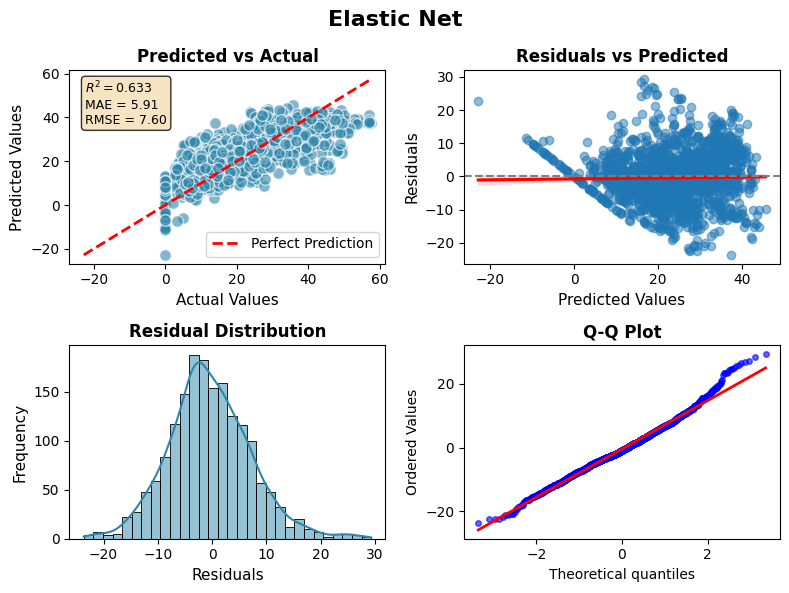

In [6]:
y_pred= comparacion.elastic_net()
comparacion.create_entry(y_pred,"Elastic Net",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Elastic Net")


## Decision Tree

The Mean Absolute Error (MAE) is 3.2656268572849987.
The Mean Squred Error(MSE) is 23.31616177323097.
The Root Mean Squared Error(RMSE) is 4.8286811629295805.
The R2 Score is 0.8519479591989977.
Adjusted R2 is 0.8502373636958087.


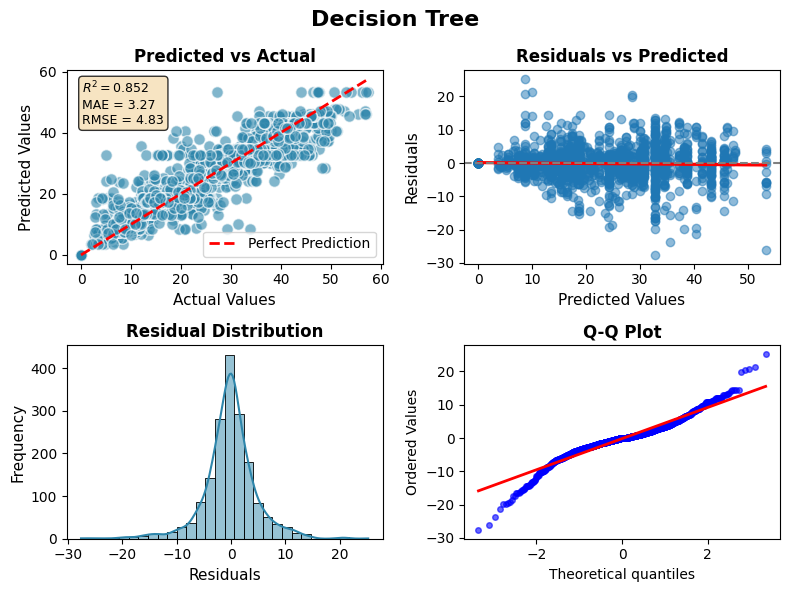

In [7]:
y_pred = comparacion.decision_tree()
comparacion.create_entry(y_pred,"Decision Tree",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Decision Tree")


## Random Forest

The Mean Absolute Error (MAE) is 2.2781949127885213.
The Mean Squred Error(MSE) is 12.282708320267188.
The Root Mean Squared Error(RMSE) is 3.5046695022879386.
The R2 Score is 0.9220077450540429.
Adjusted R2 is 0.9211066213689365.


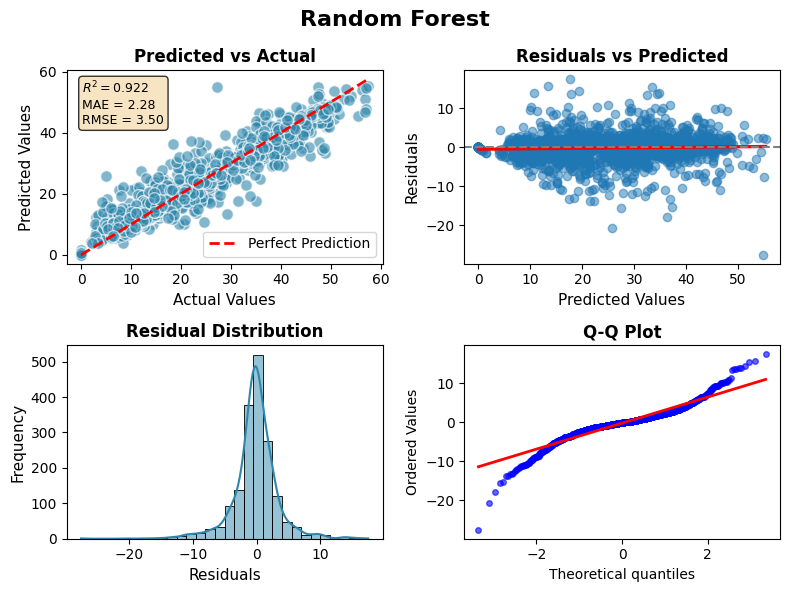

In [8]:
y_pred = comparacion.random_forest()
comparacion.create_entry(y_pred,"Random Forest",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Random Forest")

## Gradient Boosting

The Mean Absolute Error (MAE) is 2.518998595330418.
The Mean Squred Error(MSE) is 13.774755733485577.
The Root Mean Squared Error(RMSE) is 3.7114358048450167.
The R2 Score is 0.9125336014686929.
Adjusted R2 is 0.9115230133862977.


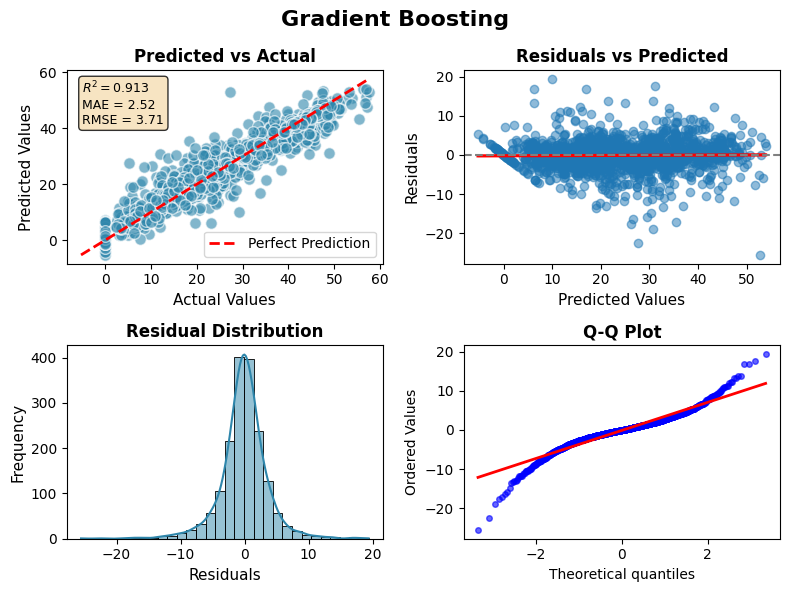

In [9]:
y_pred = comparacion.gradient_boosting()
comparacion.create_entry(y_pred,"Gradient Boosting",comparacion.comparison_table)
comparacion.plot_results(y_pred,"Gradient Boosting")


## Resultados (Sin GridSearchCV)

La siguiente tabla muestra los resultados de los distintos modelos, sin hacer uso de `GridSearchCV`

In [10]:
comparacion.comparison_table

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Linear Regression,5.9045,57.7927,7.6021,0.6330,0.6288
1,Lasso,5.9057,57.8246,7.6043,0.6328,0.6286
2,Ridge,5.9045,57.7926,7.6021,0.6330,0.6288
3,Elastic Net,5.9064,57.7911,7.6020,0.6330,0.6288
4,Decision Tree,3.2656,23.3162,4.8287,0.8519,0.8502
5,Random Forest,2.2782,12.2827,3.5047,0.9220,0.9211
6,Gradient Boosting,2.5190,13.7748,3.7114,0.9125,0.9115


Como podemos ver, los mejores modelos resultaron ser `Random Forest` y `Gradient Boosting`. Pero, no hemos optimizado los parámetros aún. Procedemos a usar `GridSearchCV`. La siguiente función buscará los mejores parámetros para todos los modelos, regresara un diccionario con los parámetros para cada modelo. 

In [11]:
best_params = comparacion.grid_searching()

{'lasso': np.float64(0.0016768329368110082), 'ridge': np.float64(0.2682695795279725), 'elastic_net': {'alpha': np.float64(0.0016768329368110082), 'l1_ratio': np.float64(1.0)}, 'decision_tree': {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 20}, 'random_forest': {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}, 'gradient_boost': {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}}


Con los parámetros, correremos las predicciones otra vez, deberíamos obtener mejores resultados.

In [12]:
y_predictions = comparacion.re_run_with_better_params()


{'lasso': np.float64(0.0016768329368110082), 'ridge': np.float64(0.2682695795279725), 'elastic_net': {'alpha': np.float64(0.0016768329368110082), 'l1_ratio': np.float64(1.0)}, 'decision_tree': {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 20}, 'random_forest': {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}, 'gradient_boost': {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}}
The Mean Absolute Error (MAE) is 5.904689770471153.
The Mean Squred Error(MSE) is 57.79738231936019.
The Root Mean Squared Error(RMSE) is 7.602458965319062.
The R2 Score is 0.6330004702934742.
Adjusted R2 is 0.6287601522148314.
The Mean Absolute Error (MAE) is 5.904574173074258.
The Mean Squred Error(MSE) is 57.79187041724203.
The Root Mean Squared Error(RMSE) is 7.602096448825287.
The R2 Score is 0.6330354695512947.
Adjusted R2 is 0.6287955558546026.
The Mean Absolute Error (MAE) is 5.904689770471153.
The Mean Squred Error(MSE) is 57.79738231936019.
The Root Mean Squared

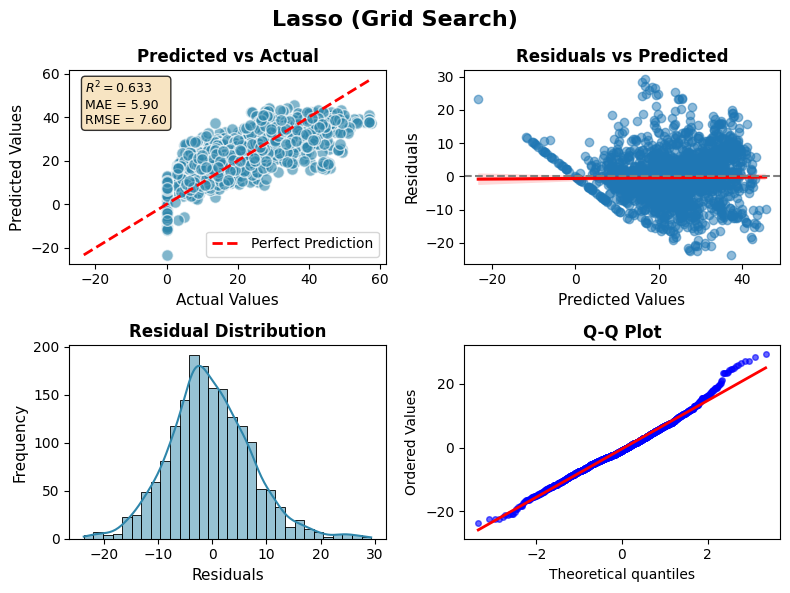

In [13]:
comparacion.plot_results(y_predictions["lasso"],"Lasso (Grid Search)")


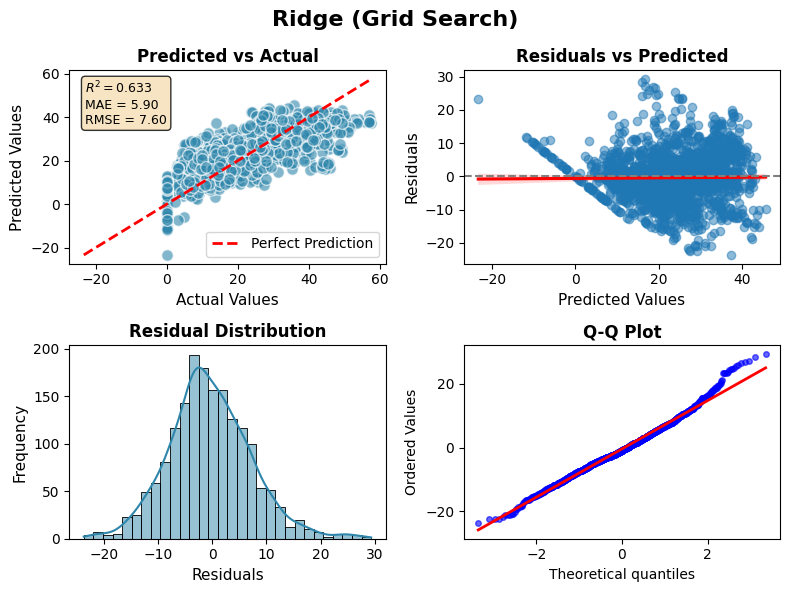

In [14]:
comparacion.plot_results(y_predictions["ridge"],"Ridge (Grid Search)")


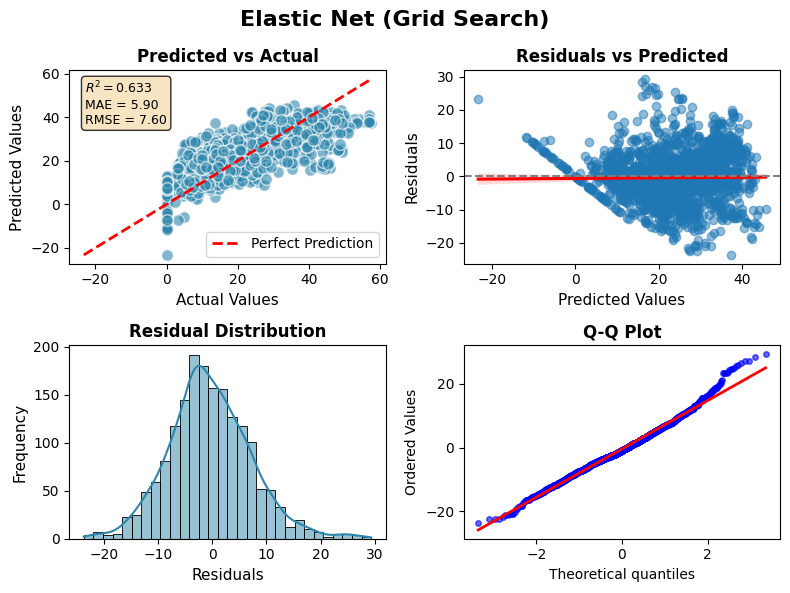

In [15]:
comparacion.plot_results(y_predictions["elastic_net"],"Elastic Net (Grid Search)")


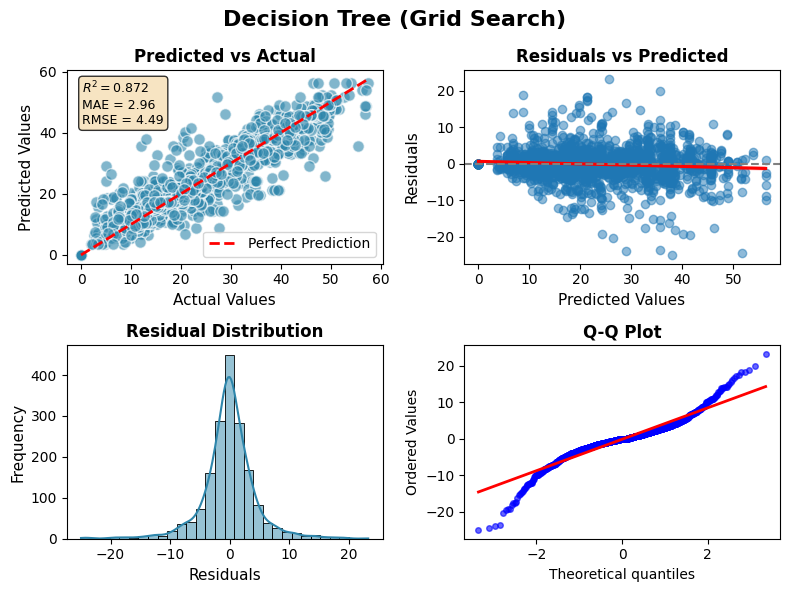

In [16]:
comparacion.plot_results(y_predictions["decision_tree"],"Decision Tree (Grid Search)")


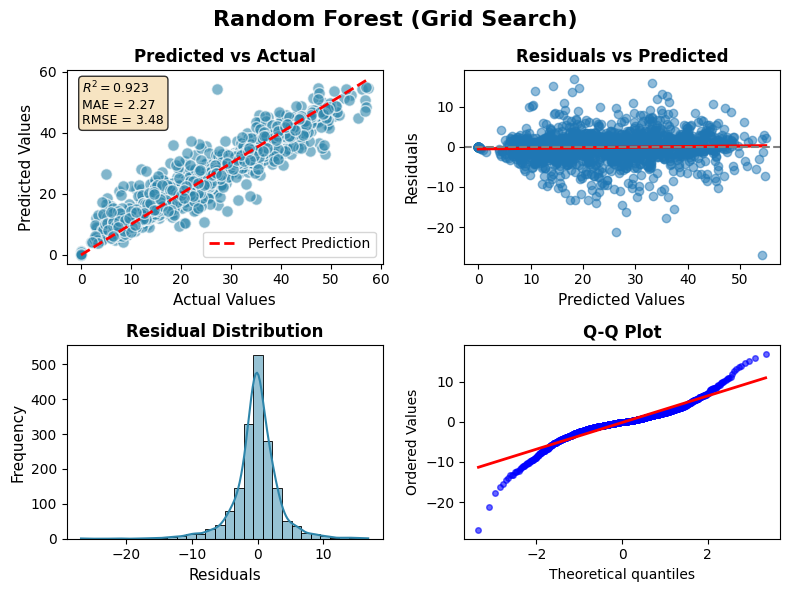

In [17]:
comparacion.plot_results(y_predictions["random_forest"],"Random Forest (Grid Search)")


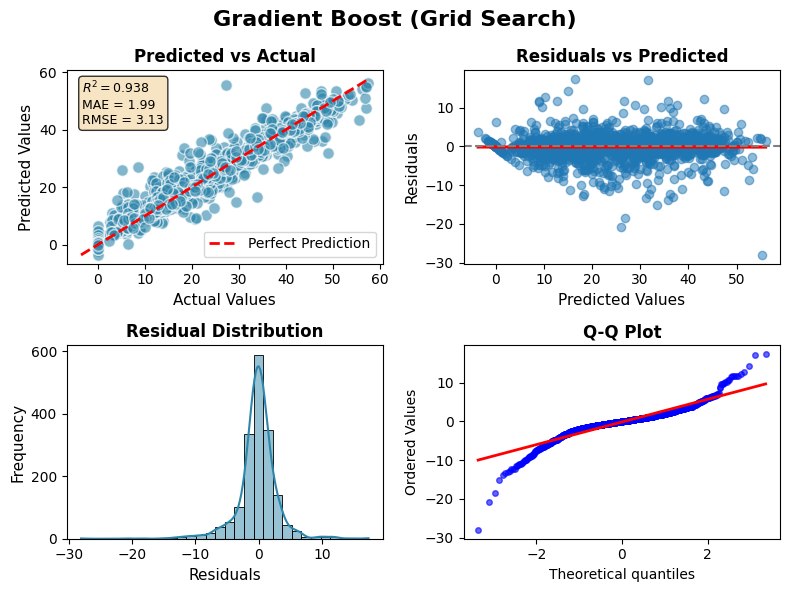

In [18]:
comparacion.plot_results(y_predictions["gradient_boost"],"Gradient Boost (Grid Search)")


## Comparativa de resultados

A continuación, una comparación entre ambas tablas, la primera es con `GridSearchCV`:

In [19]:
comparacion.grid_search_comparison_table

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Lasso (Grid Search),5.9047,57.7974,7.6025,0.6330,0.6288
1,Ridge (Grid Search),5.9046,57.7919,7.6021,0.6330,0.6288
2,Elastic Net (Grid Search),5.9047,57.7974,7.6025,0.6330,0.6288
3,Decision Tree (Grid Search),2.9559,20.1643,4.4905,0.8720,0.8705
4,Random Forest (Grid Search),2.2672,12.1011,3.4787,0.9232,0.9223
5,Gradient Boost (Grid Search),1.9871,9.8072,3.1316,0.9377,0.9370


In [20]:
comparacion.comparison_table

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Linear Regression,5.9045,57.7927,7.6021,0.6330,0.6288
1,Lasso,5.9057,57.8246,7.6043,0.6328,0.6286
2,Ridge,5.9045,57.7926,7.6021,0.6330,0.6288
3,Elastic Net,5.9064,57.7911,7.6020,0.6330,0.6288
4,Decision Tree,3.2656,23.3162,4.8287,0.8519,0.8502
5,Random Forest,2.2782,12.2827,3.5047,0.9220,0.9211
6,Gradient Boosting,2.5190,13.7748,3.7114,0.9125,0.9115


Podemos notar que el `GridSearch` sí mejoró los resultados. Random Forest ya era bueno asi que las mejoras fueron pequeñas. `Gradient Boosting` mejoró significamente. Son estos dos los mejores de todos los modelos usados.Las features con más peso fueron:

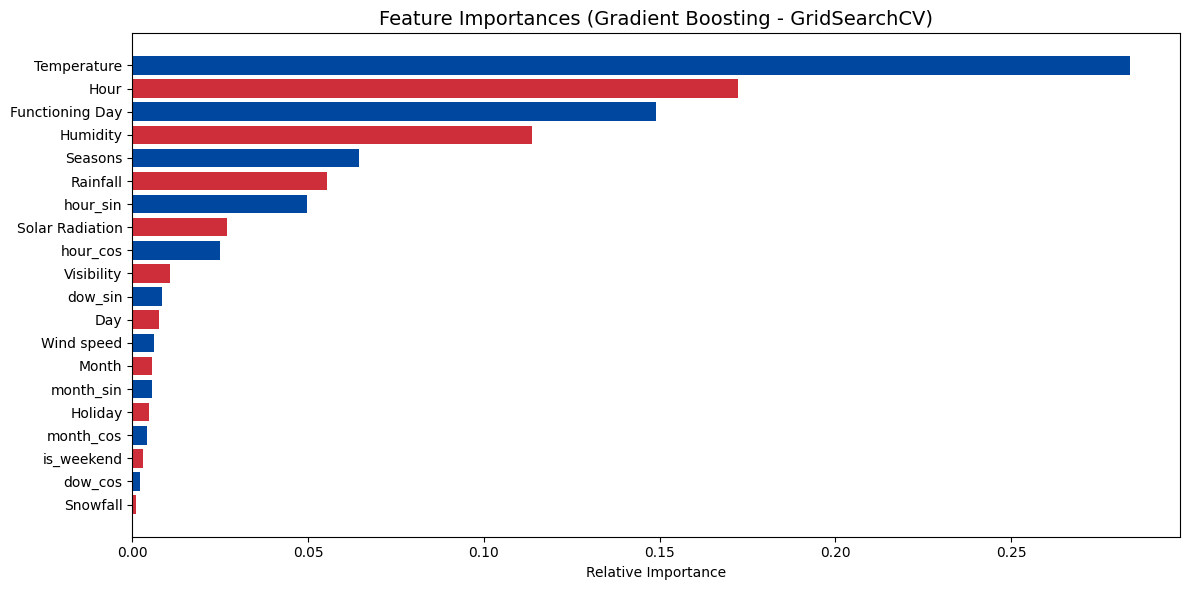

In [21]:
comparacion.most_important_features()

## GLM Poisson: Justificación

Nuestra variable target está compuesto de enteros no negativos: 

In [22]:
comparacion.dataframe["Rented Bike Count"][0:10]

0    254
1    204
2    173
3    107
4     78
5    100
6    181
7    460
8    930
9    490
Name: Rented Bike Count, dtype: int64

Una regresión lineal estandar incorrectamente intentaría predecir valores negativos y además, la regresión lineal estándar asume **homoscedasticidad**. Como nuestra variable target es un conteo, esta suposición **no** se cumple, ya que la varianza crece con la media.


De hecho, podemos notar en los gráficos de arriba ese patrón de **heteroscedasticidad** con los residuales, como por ejemplo:


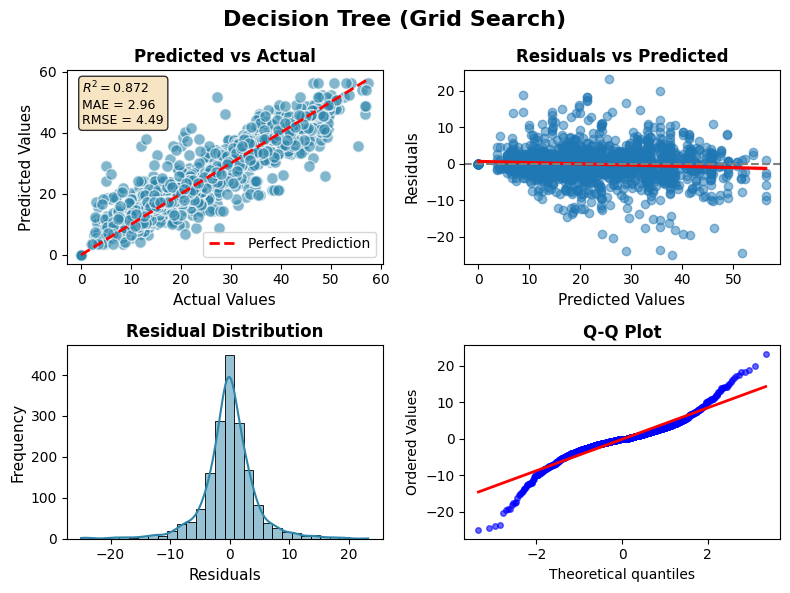

In [23]:
comparacion.plot_results(y_predictions["decision_tree"],"Decision Tree (Grid Search)")


Ahora, un modelo `GLM Poisson` modela el logaritmo de la media y explicitamente asume que la varianza es igual a la media, usa un esquema de pesos ponderados. Esto en teoría debería resolver el problema de **heteroscedasticidad**. Para prestarle atención a la estacionalidad temporal, hicimos lo siguiente con el dataframe en la etapa de limpieza:

In [24]:
import numpy as np
def make_sin_cos(self):
        self.dataframe['hour_sin'] = np.sin(2 * np.pi * self.dataframe['Hour'] / 24)
        self.dataframe['hour_cos'] = np.cos(2 * np.pi * self.dataframe['Hour'] / 24)
        self.dataframe['dow_sin'] = np.sin(2 * np.pi * self.dataframe['Day'] / 7)
        self.dataframe['dow_cos'] = np.cos(2 * np.pi * self.dataframe['Day'] / 7)

        self.dataframe['month_sin'] = np.sin(2 * np.pi * self.dataframe['Month'] / 12)
        self.dataframe['month_cos'] = np.cos(2 * np.pi * self.dataframe['Month'] / 12)

Esta función nos ayuda a incluir esta información de estacionalidad temporal, puesto que la hora 23 estaría "cerca" de la hora 0. Esto ayudará a que `GLM Poisson` tome en cuenta los "picos" de demanda de las 8:00AM y 6:00PM que notamos en el EDA. De no incluir lo de arriba, el modelo buscaría una tendencia monotona , lo cual no brinda mucha información ni es representativo de lo que pasa en la vida real.

The Mean Absolute Error (MAE) is 5.461872033796269.
The Mean Squred Error(MSE) is 53.312026417110836.
The Root Mean Squared Error(RMSE) is 7.301508502844521.
The R2 Score is 0.6614814055994405.
Adjusted R2 is 0.6575701566751128.


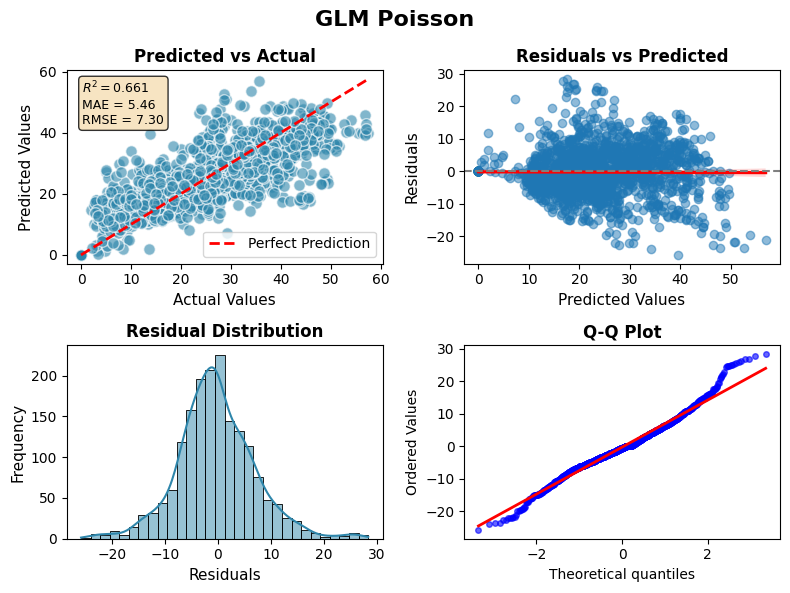

In [25]:
y_pred = comparacion.poisson_GLM()
comparacion.create_entry(y_pred,"GLM Poisson",comparacion.grid_search_comparison_table)
comparacion.plot_results(y_pred,"GLM Poisson")

In [26]:
comparacion.grid_search_comparison_table

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Lasso (Grid Search),5.9047,57.7974,7.6025,0.6330,0.6288
1,Ridge (Grid Search),5.9046,57.7919,7.6021,0.6330,0.6288
2,Elastic Net (Grid Search),5.9047,57.7974,7.6025,0.6330,0.6288
3,Decision Tree (Grid Search),2.9559,20.1643,4.4905,0.8720,0.8705
4,Random Forest (Grid Search),2.2672,12.1011,3.4787,0.9232,0.9223
5,Gradient Boost (Grid Search),1.9871,9.8072,3.1316,0.9377,0.9370
6,GLM Poisson,5.4619,53.3120,7.3015,0.6615,0.6576


Parece no haber vencido al Gradient Boost o a Random Forest. Intentaremos usar statsmodel para ver si cambia algo:

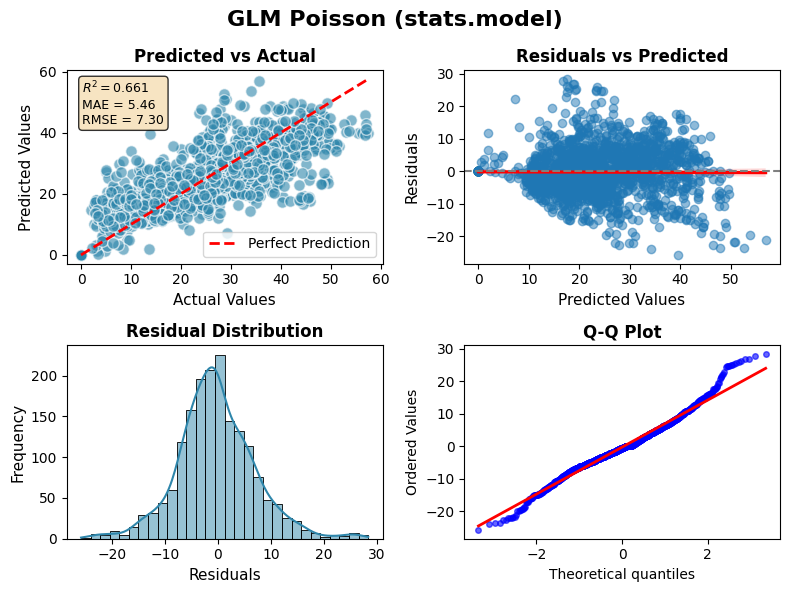

The Mean Absolute Error (MAE) is 5.461857069096921.
The Mean Squred Error(MSE) is 53.31187800404018.
The Root Mean Squared Error(RMSE) is 7.301498339658798.
The R2 Score is 0.6614823479868799.
Adjusted R2 is 0.6575711099509108.


In [38]:
import statsmodels.api as sm
new_X_train = comparacion.X_train.astype(float)
new_X_test = comparacion.X_test.astype(float)
# Add constant and fit
X_train_const = sm.add_constant(new_X_train)
poisson_sm = sm.GLM(comparacion.y_train, X_train_const, family=sm.families.Poisson()).fit()

# Check predictions on test
X_test_const = sm.add_constant(new_X_test)
y_pred_sm = poisson_sm.predict(X_test_const)
comparacion.plot_results(y_pred_sm,"GLM Poisson (stats.model)")
comparacion.create_entry(y_pred_sm,"GLM Poisson (stats.model) ",comparacion.grid_search_comparison_table)



Parece no ayudar mucho. Ahora intentaremos una Binomial Negativa.

/home/yamorza/Documentos/espacio_trabajo_intro_analisis_dat2/proyecto_modulo_5/.proyecto_5_env/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3663: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
/home/yamorza/Documentos/espacio_trabajo_intro_analisis_dat2/proyecto_modulo_5/.proyecto_5_env/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/home/yamorza/Documentos/espacio_trabajo_intro_analisis_dat2/proyecto_modulo_5/.proyecto_5_env/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3470: RuntimeWarning: overflow encountered in multiply
  dparams = exog*a1 * (y-mu)/(mu+a1)
/home/yamorza/Documentos/espacio_trabajo_intro_analisis_dat2/proyecto_modulo_5/.proyecto_5_env/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3470: RuntimeWarning: invalid value encountered in multiply
  dparam

         Current function value: 4.042500
         Iterations: 0
         Function evaluations: 13
         Gradient evaluations: 2


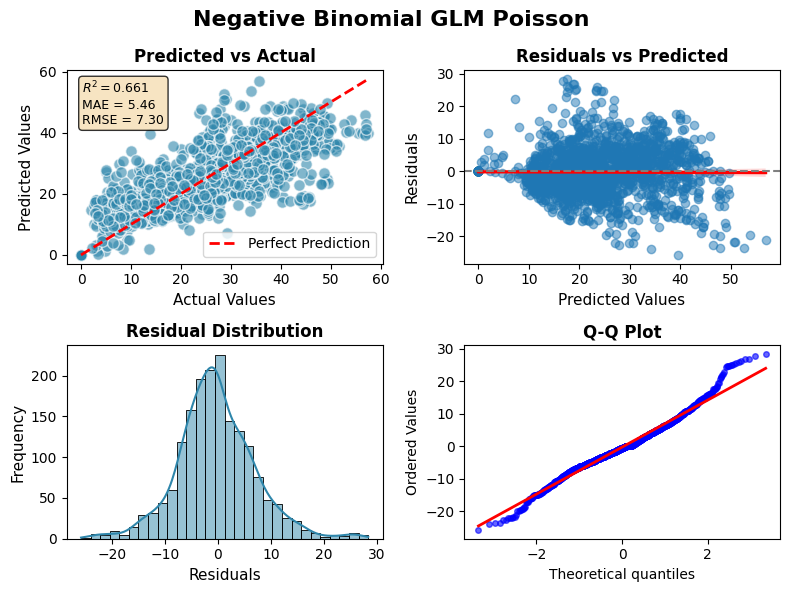

The Mean Absolute Error (MAE) is 5.461860635708471.
The Mean Squred Error(MSE) is 53.31187800456537.
The Root Mean Squared Error(RMSE) is 7.301498339694763.
The R2 Score is 0.6614823479835451.
Adjusted R2 is 0.6575711099475375.


In [40]:
from statsmodels.discrete.discrete_model import NegativeBinomial
new_X_train = comparacion.X_train.astype(float)
new_X_test = comparacion.X_test.astype(float)
nb_model = NegativeBinomial(comparacion.y_train, X_train_const).fit()
y_pred_nb = nb_model.predict(X_test_const)
comparacion.plot_results(y_pred_nb,"Negative Binomial GLM Poisson ")
comparacion.create_entry(y_pred_nb,"Negative Binomial GLM",comparacion.grid_search_comparison_table)

In [41]:
comparacion.grid_search_comparison_table

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Lasso (Grid Search),5.9047,57.7974,7.6025,0.6330,0.6288
1,Ridge (Grid Search),5.9046,57.7919,7.6021,0.6330,0.6288
2,Elastic Net (Grid Search),5.9047,57.7974,7.6025,0.6330,0.6288
3,Decision Tree (Grid Search),2.9559,20.1643,4.4905,0.8720,0.8705
4,Random Forest (Grid Search),2.2672,12.1011,3.4787,0.9232,0.9223
5,Gradient Boost (Grid Search),1.9871,9.8072,3.1316,0.9377,0.9370
6,GLM Poisson,5.4619,53.3120,7.3015,0.6615,0.6576
7,GLM Poisson (stats.model),5.4619,53.3119,7.3015,0.6615,0.6576
8,Negative Binomial GLM,5.4619,53.3119,7.3015,0.6615,0.6576


## Conclusion:
Sorprendentemente, a pesar de haber un uso de justificado de una `GLM de Poisson`, esta no parece vencer a `Gradient Boost` o a `Random Forest`. Esto a pesar de haber incluido estacionalidad temporal. 


A pesar de que una GLM de Poisson es teoricamente la más apropiada para datos de conteo, la presencia de no linealidad, interacciones entre variables, etc la hacen inferior a modelos basados en árboles en el perfomance de predicción. Esto se alinea con lo mencionado en clase y en otros estudios, que muestran que la flexibilidad de estos metodos ofrecen un mejor perfomance comparado con modelos parametricos a la hora de trabajar con data que tiene temporalidad estacional.